In [ ]:
COLLABORATORS_NAME = ""
COLLABORATORS_ID = ""

In [ ]:
!pip -q install torch torchaudio
!pip -q install scikit-learn matplotlib tqdm

In [ ]:
import os, random, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:

from torchaudio.datasets import SPEECHCOMMANDS

root = "./data_speechcommands"
os.makedirs(root, exist_ok=True)

In [ ]:
!pip -q install torchcodec

In [ ]:
TARGET_LABELS = ["up", "down", "left", "right"]
label_to_idx = {l: i for i, l in enumerate(TARGET_LABELS)}
idx_to_label = {i: l for l, i in label_to_idx.items()}

train_base = SPEECHCOMMANDS(root, subset="training", download=True)
val_base   = SPEECHCOMMANDS(root, subset="validation", download=True)
test_base  = SPEECHCOMMANDS(root, subset="testing", download=True)

Only taking the data with labels up, down, left, right.

In [ ]:
class FilteredSpeechCommands(Dataset):
    def __init__(self, base_ds, allowed_labels, max_items=None, seed=42):
        self.allowed = set(allowed_labels)
        self.idxs = [i for i in range(len(base_ds)) if base_ds[i][2] in self.allowed]

        # Quick subsample for faster experimentation
        if max_items is not None and len(self.idxs) > max_items:
            rng = np.random.default_rng(seed)
            self.idxs = rng.choice(self.idxs, size=max_items, replace=False).tolist()

        self.base = base_ds

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        return self.base[self.idxs[i]]

train_set = FilteredSpeechCommands(train_base, TARGET_LABELS, max_items=3000)
val_set   = FilteredSpeechCommands(val_base,   TARGET_LABELS, max_items=3000)
test_set  = FilteredSpeechCommands(test_base,  TARGET_LABELS, max_items=3000)

print("Using labels:", TARGET_LABELS)
print("Train/Val/Test sizes:", len(train_set), len(val_set), len(test_set))

Using labels: ['up', 'down', 'left', 'right']
Train/Val/Test sizes: 3000 1442 1639


In [ ]:
TARGET_SR = 16000
TARGET_LEN = 16000  # 1 sec at 16kHz

def pad_or_crop_1d(x, target_len=TARGET_LEN):
    T = x.shape[-1]
    if T == target_len:
        return x
    if T < target_len:
        return F.pad(x, (0, target_len - T))
    return x[:target_len]

# Choose your parameters
N_FFT = 2048
HOP = 512
WIN = 2048

# Write code to calculate spectrogram
spectrogram_tf =  torchaudio.transforms.Spectrogram(
    n_fft=N_FFT,
    hop_length=HOP,
    win_length=WIN,
    power=2.0,
    center=True
    )


def make_stft_features(wave_1d):
    """
    wave_1d: (T,) float tensor
    returns: (1, F, TT) log-power spectrogram
    """
    spec = spectrogram_tf(wave_1d.unsqueeze(0))  # (1, F, TT)
    spec = torch.log1p(spec)
    return spec

In [ ]:
class SpecDataset(Dataset):
    def __init__(self, base_ds, label_to_idx):
        self.base = base_ds
        self.label_to_idx = label_to_idx
        self.resamplers = {}

    def _resample(self, wav, sr):
        if sr == TARGET_SR:
            return wav
        if sr not in self.resamplers:
            self.resamplers[sr] = torchaudio.transforms.Resample(sr, TARGET_SR)
        return self.resamplers[sr](wav)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        wav, sr, label, *_ = self.base[idx]  # wav: (1, T)
        wav = self._resample(wav, sr)[0]     # (T,)



        wav = (wav - wav.mean()) / (wav.std() + 1e-6)

        # fixed length
        wav = pad_or_crop_1d(wav, TARGET_LEN)

        # STFT
        spec = make_stft_features(wav)       # (1, F, TT)

        y = self.label_to_idx[label]         # 0..3
        return wav.float(), spec.float(), torch.tensor(y, dtype=torch.long)

train_ds = SpecDataset(train_set, label_to_idx)
val_ds   = SpecDataset(val_set,   label_to_idx)
test_ds  = SpecDataset(test_set,  label_to_idx)

x_raw, x_spec, y = train_ds[0]
print("raw:", x_raw.shape, "spec:", x_spec.shape, "y:", y.item(), idx_to_label[y.item()])

raw: torch.Size([16000]) spec: torch.Size([1, 1025, 32]) y: 2 left


In [ ]:
BATCH = 128
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

In [ ]:
num_classes = 4

class SpecOnlyModel(nn.Module):
# Define your model, your model should achieve at least 60% accuracy
    def __init__(self, num_classes=4):
        super().__init__()

        # Input: (batch, 1, F, T) where F=257 (from n_fft=512), T~63

        # Convolutional blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)  # -> (32, F/2, T/2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)  # -> (64, F/4, T/4)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)  # -> (128, F/8, T/8)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # -> (256, 1, 1)
        )

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, raw, spec):
        """
        raw: (batch, T) - raw waveform (not used in this model)
        spec: (batch, 1, F, T) - spectrogram features
        """
        # Use only spectrogram features
        x = self.conv1(spec)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Flatten
        x = x.view(x.size(0), -1)  # (batch, 256)

        # Classify
        x = self.fc(x)

        return x




In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_y = [], []
    total_loss, total = 0.0, 0

    for raw, spec, y in loader:
        raw, spec, y = raw.to(device), spec.to(device), y.to(device)
        logits = model(raw, spec)
        loss = F.cross_entropy(logits, y)

        total_loss += loss.item() * y.size(0)
        total += y.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_y.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_y = np.concatenate(all_y)

    acc = (all_preds == all_y).mean()
    macro_f1 = f1_score(all_y, all_preds, average="macro")
    return total_loss/total, acc, macro_f1, all_y, all_preds


def train_model(model, train_loader, val_loader, epochs=6, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_f1 = -1
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        running_loss, total = 0.0, 0

        for raw, spec, y in tqdm(train_loader, desc=f"Epoch {ep}/{epochs}"):
            raw, spec, y = raw.to(device), spec.to(device), y.to(device)

            opt.zero_grad()
            logits = model(raw, spec)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

            running_loss += loss.item() * y.size(0)
            total += y.size(0)

        train_loss = running_loss / total
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

        print(f"Epoch {ep}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_macroF1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


In [ ]:
EPOCHS = 10 # You can adjust the number if you feel necessary
LR = 1e-3 # You can adjust the number if you feel necessary

spec_model = SpecOnlyModel(num_classes=num_classes)
spec_model = train_model(spec_model, train_loader, val_loader, epochs=EPOCHS, lr=LR)


Epoch 1/10:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1: train_loss=1.2195 | val_loss=2.0535 | val_acc=0.2469 | val_macroF1=0.1105


Epoch 2/10:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 2: train_loss=0.9653 | val_loss=1.4108 | val_acc=0.4508 | val_macroF1=0.4184


Epoch 3/10:   0%|          | 0/24 [00:00<?, ?it/s]

...

Epoch 8: train_loss=0.5308 | val_loss=1.6475 | val_acc=0.5513 | val_macroF1=0.4680


Epoch 9/10:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 9: train_loss=0.5177 | val_loss=1.1306 | val_acc=0.6290 | val_macroF1=0.5960


Epoch 10/10:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 10: train_loss=0.5237 | val_loss=1.3464 | val_acc=0.5610 | val_macroF1=0.5023



Test Loss: 0.6623
Test Accuracy: 0.7486 (74.86%)
Test Macro F1: 0.7473
CLASSIFICATION REPORT
              precision    recall  f1-score   support

          up     0.8674    0.7388    0.7980       425
        down     0.8152    0.8473    0.8309       406
        left     0.6477    0.8034    0.7172       412
       right     0.6919    0.6010    0.6432       396

    accuracy                         0.7486      1639
   macro avg     0.7555    0.7476    0.7473      1639
weighted avg     0.7568    0.7486    0.7485      1639



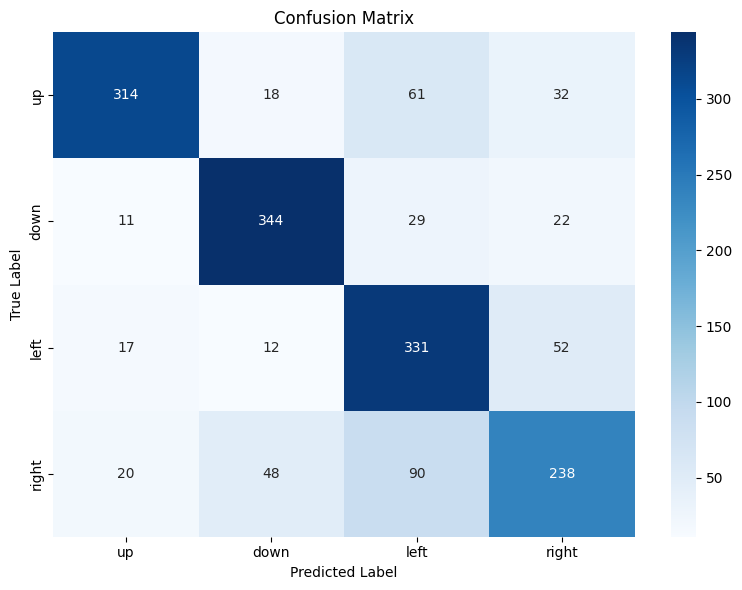

In [ ]:
# Write code to show classification report and confusion matrix
test_loss, test_acc, test_f1, y_true, y_pred = evaluate(spec_model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Macro F1: {test_f1:.4f}")

# Classification Report

print("CLASSIFICATION REPORT")

print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS)
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

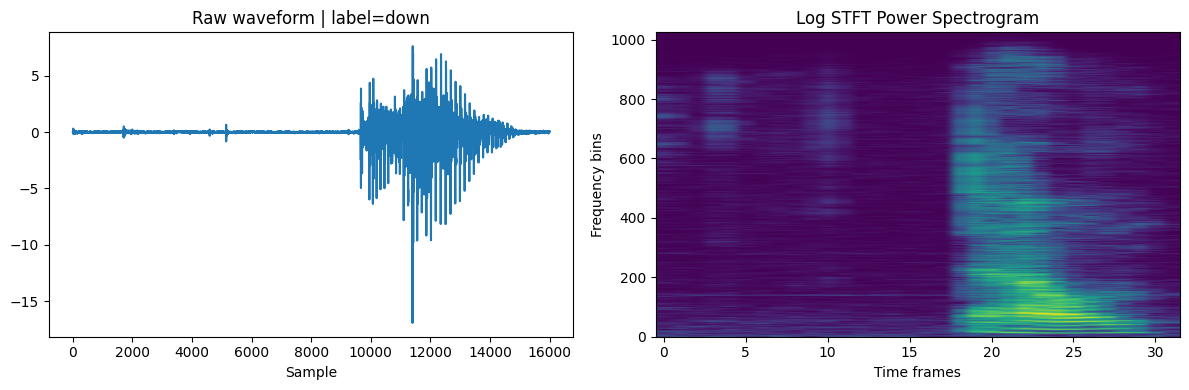

In [ ]:
raw, spec, y = train_ds[100]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(raw.numpy())
plt.title(f"Raw waveform | label={idx_to_label[y.item()]}")
plt.xlabel("Sample")

plt.subplot(1,2,2)
plt.imshow(spec[0].numpy(), aspect="auto", origin="lower")
plt.title("Log STFT Power Spectrogram")
plt.xlabel("Time frames")
plt.ylabel("Frequency bins")
plt.tight_layout()
plt.show()
